In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


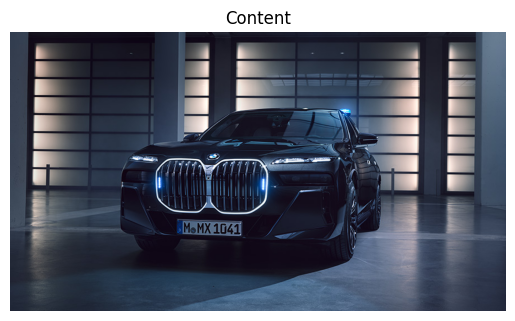

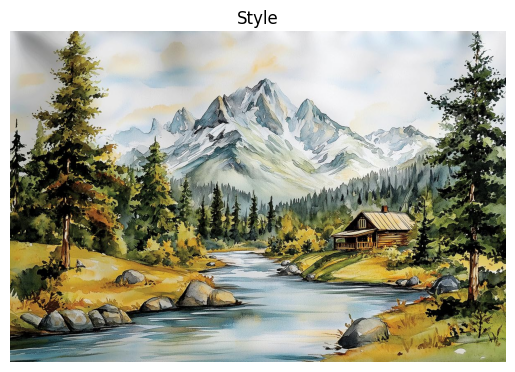

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("content.jpg")
img2 = Image.open("style.jpg")

plt.imshow(img1)
plt.title("Content")
plt.axis("off")
plt.show()

plt.imshow(img2)
plt.title("Style")
plt.axis("off")
plt.show()



🔥 Running with STYLE_WEIGHT = 500000.0
Step 20 | Loss: 1677.056396484375
Step 40 | Loss: 354.30078125
Step 60 | Loss: 190.14840698242188
Step 80 | Loss: 128.71466064453125
Step 100 | Loss: 98.57432556152344
Step 120 | Loss: 81.16437530517578
Step 140 | Loss: 69.41258239746094


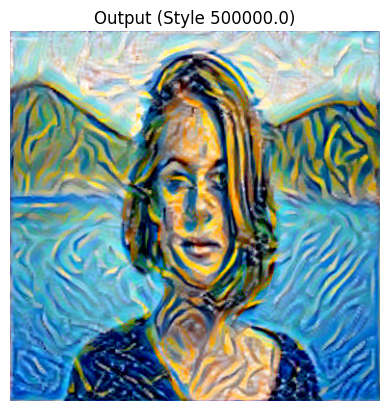


🔥 Running with STYLE_WEIGHT = 1000000.0
Step 20 | Loss: 3345.69189453125
Step 40 | Loss: 636.473876953125
Step 60 | Loss: 336.43023681640625
Step 80 | Loss: 214.21583557128906
Step 100 | Loss: 157.2545166015625
Step 120 | Loss: 117.48286437988281
Step 140 | Loss: 92.24121856689453


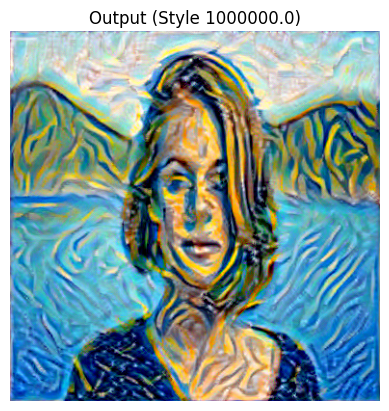


🔥 Running with STYLE_WEIGHT = 5000000.0
Step 20 | Loss: 15697.498046875
Step 40 | Loss: 3422.536376953125
Step 60 | Loss: 1607.6041259765625
Step 80 | Loss: 915.9487915039062
Step 100 | Loss: 615.2139282226562
Step 120 | Loss: 409.92974853515625
Step 140 | Loss: 287.44708251953125


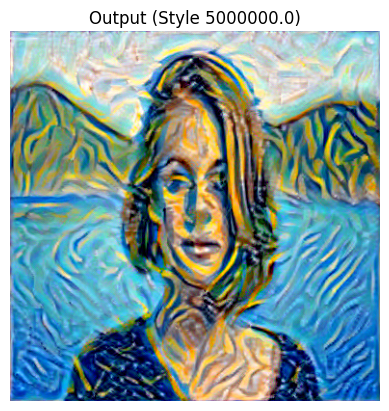


✅ All outputs generated!


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import VGG19_Weights
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.utils import save_image

device = torch.device("cpu")

# -------------------------
# USER CONTROLS (UNIQUENESS)
# -------------------------
STYLE_WEIGHTS = [5e5, 1e6, 5e6]   # multiple outputs (key feature)
CONTENT_WEIGHT = 1
TV_WEIGHT = 1e-5
STEPS = 120

# -------------------------
# Preprocessing
# -------------------------
loader = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor()
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    img = loader(img).unsqueeze(0)
    return img.to(device, torch.float)

content = load_image("content.jpg")
style = load_image("style.jpg")

# -------------------------
# Display
# -------------------------
def imshow(tensor, title):
    image = tensor.cpu().clone().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

# -------------------------
# Normalization (IMPORTANT)
# -------------------------
mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1,1,1)
        self.std = std.view(-1,1,1)

    def forward(self, x):
        return (x - self.mean) / self.std

# -------------------------
# Losses
# -------------------------
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, x):
        self.loss = F.mse_loss(x, self.target)
        return x

def gram_matrix(x):
    b, c, h, w = x.size()
    features = x.view(b*c, h*w)
    G = torch.mm(features, features.t())
    return G.div(b*c*h*w)

class StyleLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = gram_matrix(target).detach()

    def forward(self, x):
        G = gram_matrix(x)
        self.loss = F.mse_loss(G, self.target)
        return x

# -------------------------
# Build model
# -------------------------
def build_model(cnn, style_img, content_img):
    normalization = Normalization(mean, std).to(device)

    content_layers = ['conv_4']
    style_layers = ['conv_1','conv_2','conv_3','conv_4','conv_5']

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():

        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            cl = ContentLoss(target)
            model.add_module(f"content_loss_{i}", cl)
            content_losses.append(cl)

        if name in style_layers:
            target = model(style_img).detach()
            sl = StyleLoss(target)
            model.add_module(f"style_loss_{i}", sl)
            style_losses.append(sl)

    # trim extra layers
    for i in range(len(model)-1, -1, -1):
        if isinstance(model[i], (ContentLoss, StyleLoss)):
            break
    model = model[:i+1]

    return model, style_losses, content_losses

# -------------------------
# Run NST
# -------------------------
def run_style_transfer(style_weight):

    print(f"\n🔥 Running with STYLE_WEIGHT = {style_weight}")

    input_img = content.clone().requires_grad_(True)

    cnn = models.vgg19(weights=VGG19_Weights.DEFAULT).features.to(device).eval()
    model, style_losses, content_losses = build_model(cnn, style, content)

    optimizer = optim.LBFGS([input_img])

    run = [0]
    while run[0] <= STEPS:

        def closure():
            optimizer.zero_grad()

            input_img.data.clamp_(0,1)

            model(input_img)

            style_score = sum(sl.loss for sl in style_losses)
            content_score = sum(cl.loss for cl in content_losses)

            # TV Loss (smoothness)
            tv_loss = torch.sum(torch.abs(input_img[:, :, :, :-1] - input_img[:, :, :, 1:])) + \
                      torch.sum(torch.abs(input_img[:, :, :-1, :] - input_img[:, :, 1:, :]))

            loss = (style_score * style_weight) + \
                   (content_score * CONTENT_WEIGHT) + \
                   (tv_loss * TV_WEIGHT)

            loss.backward()

            run[0] += 1
            if run[0] % 20 == 0:
                print(f"Step {run[0]} | Loss: {loss.item()}")

            return loss

        optimizer.step(closure)

    input_img.data.clamp_(0,1)

    # show + save
    imshow(input_img, f"Output (Style {style_weight})")
    save_image(input_img, f"output_{int(style_weight)}.jpg")


# -------------------------
# MAIN EXECUTION
# -------------------------
for w in STYLE_WEIGHTS:
    run_style_transfer(w)

print("\n✅ All outputs generated!")